In [1]:
import importlib
from preprocess_behav2p import DataLoader
import preprocess_behav2p as preprocess
# MODULES
import os
import yaml
from pathlib import Path
from typing import Optional
import importlib.util
import numpy as np
import pandas as pd
import scipy.io
from io_utils import save_pickle, load_pickle
from scipy import signal
from scipy.ndimage import gaussian_filter1d
from scipy.signal import correlate
from sklearn.linear_model import LinearRegression
from skimage.measure import EllipseModel
import matplotlib.pyplot as plt

In [3]:
# checked the functions for processing pupil data --- looks good? tho not entirely sure about the decimate part

'''
1. DLC output csv files look good
2. dlc_path first find the filtered csv files - threshold unknown but should be fine
one thing to mention: here it uses a threshold again on the filtered csv files. is it necessary?
3. extract_pupil_from_dlc looks correct
bin_and_average_dlc --- something might go wrong in binning? otherwise should be fine
'''

dlc_path = DataLoader.find_pupil_dlc_output(r"Y:\public\projects\SaEl_20220201_VIP\2pdata\LC\vipsilencing\flphalotest\BY_566\behavior_data")
x,y,p = DataLoader.load_dlc_points(dlc_path) 
data = DataLoader.extract_pupil_from_dlc(x, y, p, jump_thresh=20, min_points=5)
pupil_area = data['pupil_area']
pupil_diameter = data['pupil_diameter']
pupil_long_axis = data['pupil_long_axis']

In [5]:
@staticmethod
def find_pupil_dlc_output(behavior_data_path: str) -> Optional[str]:
    bp = Path(behavior_data_path)

    # Prefer CSV always
    cands = (
        sorted(bp.glob("*PupilCamera*DLC*filtered*.csv")) +
        sorted(bp.glob("*PupilCamera*DLC*.csv"))
    )
    if cands:
        return str(cands[0])

    has_tables = importlib.util.find_spec("tables") is not None
    if not has_tables:
        return None

    cands = (
        sorted(bp.glob("*PupilCamera*DLC*filtered*.h5")) +
        sorted(bp.glob("*PupilCamera*DLC*.h5"))
    )
    return str(cands[0]) if cands else None

In [6]:
@staticmethod
def load_dlc_points(dlc_path: str):
    """Return x,y,p arrays (frames x points). Works for DLC CSV or H5.
    Note: H5 needs pytables; if missing, user should install or export CSV.
    """
    dlc_path = Path(dlc_path)
    if dlc_path.suffix.lower() == ".h5":
        df = pd.read_hdf(dlc_path)  # requires pytables
        x = df.xs("x", level="coords", axis=1).to_numpy()
        y = df.xs("y", level="coords", axis=1).to_numpy()
        p = df.xs("likelihood", level="coords", axis=1).to_numpy()
        return x, y, p

    df = pd.read_csv(dlc_path, skiprows=3, header=None)
    # DLC csv is [x1 y1 p1 x2 y2 p2 ...] (often with a first "frame" col)
    arr = df.to_numpy()
    if arr.shape[1] % 3 == 1:
        arr = arr[:, 1:] 
    x = arr[:, 0::3]
    y = arr[:, 1::3]
    p = arr[:, 2::3]  # looks correct
    return x, y, p

In [ ]:
@staticmethod
def extract_pupil_from_dlc(x, y, p, conf_thresh=0.95, jump_thresh=20, min_points=5):
    n = x.shape[0]

    good = p > conf_thresh
    dx = np.abs(np.diff(x, axis=0, prepend=x[[0]]))
    dy = np.abs(np.diff(y, axis=0, prepend=y[[0]]))
    good &= ~((dx > jump_thresh) | (dy > jump_thresh)) # filter by conf_thresh and jump_thresh

    area = np.full(n, np.nan)
    diameter = np.full(n, np.nan)
    long_axis = np.full(n, np.nan)
    cx = np.full(n, np.nan)
    cy = np.full(n, np.nan)

    ell = EllipseModel()

    for i in range(n):
        ok = good[i] & np.isfinite(x[i]) & np.isfinite(y[i])
        xi, yi = x[i, ok], y[i, ok]
        if xi.size < min_points:
            continue   # if too few points then jump to the next iteration

        mx, my = np.median(xi), np.median(yi)
        madx = np.median(np.abs(xi - mx)) + 1e-9
        mady = np.median(np.abs(yi - my)) + 1e-9
        keep = (np.abs(xi - mx) < 2 * madx) & (np.abs(yi - my) < 2 * mady)
        xi, yi = xi[keep], yi[keep]
        if xi.size < min_points:  # looks correct
            continue

        if not ell.estimate(np.column_stack([xi, yi])): # fit ellipse with remaining points, if fails skip this frame
            continue

        xc, yc, a, b, _ = ell.params   # center coordinates (xc,yc), semi-major/minor axis a/b
        area[i] = np.pi * a * b # pi *a*b
        long_axis[i] = max(a, b) # longer axis
        diameter[i] = 2 * np.sqrt(a * b) # effective diameter (geometric mean of the axes, representing a circle with equivalent area)
        cx[i], cy[i] = xc, yc 

    return {
        "pupil_area": area,
        "pupil_diameter": diameter,
        "pupil_long_axis": long_axis,
        "pupil_center_x": cx,
        "pupil_center_y": cy,
    }


In [9]:
def bin_and_average_dlc(self, x, y, p, cam_frame_time, bin_starts):
    T, n_pts = x.shape
    N = len(bin_starts)

    bin_idx = np.searchsorted(bin_starts, cam_frame_time, side="right") - 1
    counts = np.bincount(bin_idx[(bin_idx>=0)&(bin_idx<len(bin_starts))], minlength=len(bin_starts))

    valid = (bin_idx >= 0) & (bin_idx < N)
    if not np.any(valid):
        return (np.full((N, n_pts), np.nan),
                np.full((N, n_pts), np.nan),
                np.full((N, n_pts), np.nan))

    bin_idx = bin_idx[valid]
    x = x[valid]
    y = y[valid]
    p = p[valid]

    x_d = np.full((N, n_pts), np.nan)
    y_d = np.full((N, n_pts), np.nan)
    p_d = np.full((N, n_pts), np.nan)

    # Loop only bins that actually receive frames (faster than range(N))
    for i in np.unique(bin_idx):
        m = bin_idx == i
        x_d[i] = np.nanmean(x[m], axis=0)
        y_d[i] = np.nanmean(y[m], axis=0)
        p_d[i] = np.nanmean(p[m], axis=0)

    return x_d, y_d, p_d

In [4]:
import importlib
import pandas as pd
import sys
sys.path.insert(0, r"Y:\public\projects\SaEl_20220201_VIP\analysis-2025\analysis-2025")
import preprocess_behav2p as preprocess
import analysis_functions as af
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from scipy import stats
import os
import pickle
from matplotlib.animation import FuncAnimation
from io_utils import save_pickle, load_pickle
import init_vars as iv
import visualize as viz
import scipy
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from scipy.ndimage import gaussian_filter1d

In [ ]:
# # RELOAD 
# importlib.reload(preprocess)
# data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record.xlsx'
# sheet_name = 'LC_DREADDs'
# table = pd.read_excel(data_dir, sheet_name=sheet_name)
# comb = {}
# neuropil_factor = 0.1
# tri_perc = 1
# for ani in range(2,6):
#     # Run preprocessing for each animal/session
#     ani, pp = preprocess.main(ani, table,sheet_name, neuropil_factor, tri_perc,basesub=1, roitype='suite2p')
#     comb[ani] = {
#         'n_gratings': pp.n_gratings,
#         'unpred_trials': pp.unpred_trials,
#         'pred_trials': pp.pred_trials,
#         'trial_start_indices': pp.trial_start_indices,
#         'grating_indices': pp.grating_indices,
#         'dff_Zscore': pp.dff_Zscore,
#         'n_planes': pp.n_planes,
#         'n_trial': pp.n_trials,
#         'aligned_data': pp.aligned_data,
#         'reward_indices': pp.reward_indices,
#         'activity': pp.activity,
#         'TC': pp.TC,
#         'position': pp.position,
#         'position_tunnel': pp.position_tunnel,
#         'speed': pp.speed,
#         'trial_type': pp.trial_types,
#         'pupil': pp.pupil,
#         'lick': pp.lick
#     }

# data = {}
# importlib.reload(iv)
# for ani in comb.keys():
#     data[ani] ={}
#     data[ani]['aligned_data'] = comb[ani]['aligned_data']
#     data[ani]['activity'] = comb[ani]['activity']
#     data[ani]['unpred_trials'] = comb[ani]['unpred_trials']
#     data[ani]['pred_trials'] = comb[ani]['pred_trials']
#     data[ani]['dff_Zscore'] = comb[ani]['dff_Zscore']
#     data[ani]['trial_start_indices'] = comb[ani]['trial_start_indices']
#     data[ani]['type'] = table.iloc[ani][3]
#     data[ani]['grating_indices']= comb[ani]['grating_indices']
#     data[ani]['reward_indices']= comb[ani]['reward_indices']
#     data[ani]['n_gratings'] = comb[ani]['n_gratings']
#     data[ani]['n_trial'] = comb[ani]['n_trial']
#     if table.iloc[ani][1] == 1:
#         data[ani]['position_tunnel'] = comb[ani]['position_tunnel']
#         data[ani]['position'] = comb[ani]['position']
#         data[ani]['speed'] = comb[ani]['speed']
#         data[ani]['lick'] = comb[ani]['lick']
#         data[ani]['pupil'] = comb[ani]['pupil']
#     else:
#         data[ani]['position'] = comb[ani]['aligned_data' ]['Averaged_Position']
#         try:
#             data[ani]['pupil'] = comb[ani]['aligned_data']['pupil_diameter']
#             data[ani] = iv.process_pupil(data[ani])
#         except KeyError:
#             data[ani]['pupil'] = None

#         data[ani]['speed'] = comb[ani]['aligned_data']['Speed_Absolute']
#         data[ani] = iv.process_speed(data[ani])

#     save_pickle(data[ani], "all_data", base_path=table.iloc[ani][2])

R2=0.9999999922470187 ---- Slope=1.0000167188209355 ---- intercept=0.7651887134620665
Using DLC file: PupilCamera_CameraVideoDLC_resnet50_pupil-setup2-bonsaiJan21shuffle1_500000.csv
Detected 1 excess frames in the downsampled data. Discarding these frames.
bonsai done
R2=0.9999999947148255 ---- Slope=1.000013230245732 ---- intercept=0.7012166481567874
Using DLC file: PupilCamera_CameraVideoDLC_resnet50_pupil-setup2-bonsaiJan21shuffle1_500000.csv
Detected 1 excess frames in the downsampled data. Discarding these frames.
bonsai done
R2=0.9999943120477772 ---- Slope=0.9996027026530022 ---- intercept=2.9719447284737726
Using DLC file: PupilCamera_CameraVideoDLC_resnet50_pupil-setup2-bonsaiJan21shuffle1_500000.csv
bonsai done
R2=0.9999999963043393 ---- Slope=1.0000186280177492 ---- intercept=0.7462971521076724
Using DLC file: PupilCamera_CameraVideoDLC_resnet50_pupil-setup2-bonsaiJan21shuffle1_500000.csv
Detected 1 excess frames in the downsampled data. Discarding these frames.
bonsai done


In [5]:
# LOAD DATA
importlib.reload(preprocess)
data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record.xlsx'
sheet_name = 'LC_DREADDs'
table = pd.read_excel(data_dir, sheet_name=sheet_name)
data = {}
neuropil_factor = 0.1
tri_perc = 1
ani_range = range(0,4)
for ani in ani_range:
    data[ani] = load_pickle('all_data',base_path=table.iloc[ani][2])

In [262]:
for ani in data.keys():
    pupil = data[ani]['pupil']
    if pupil is None:
        print(f"Animal {ani}: pupil is None")
    else:
        nan_count = np.sum(np.isnan(pupil))
        print(f"Animal {ani}: {nan_count} / {len(pupil)} NaN frames ({100*nan_count/len(pupil):.1f}%)")

Animal 0: 20 / 49939 NaN frames (0.0%)
Animal 1: 689 / 44687 NaN frames (1.5%)
Animal 2: 61 / 40076 NaN frames (0.2%)
Animal 3: 131 / 37836 NaN frames (0.3%)


In [373]:
baseline_frames = slice(11, 19)  # 1s pre-event window (onset at frame 19)

for ani in ani_range:
    if data[ani].get('pupil_rel') is None:
        continue
    data[ani]['pupil_rel_bs'] = {}
    for grat in data[ani]['pupil_rel']:
        epochs = data[ani]['pupil_rel'][grat].copy().astype(float)
        bad = np.mean(np.isnan(epochs), axis=1) > 0.5
        epochs[bad] = np.nan
        baseline_mean = np.nanmean(epochs[:, baseline_frames], axis=1, keepdims=True)
        data[ani]['pupil_rel_bs'][grat] = epochs - baseline_mean

In [347]:
prestim_frames = slice(15,20)
poststim_frames = slice(23,30)

In [ ]:
ani = 0
vals = np.nanmean(data[ani]['pupil_rel']['gr_1'][:,11:19],axis=1)
plt.plot(vals)
plt.xlabel('Trial')
plt.ylabel('Mean pupil before gr_1')
plt.title('C_CNO')

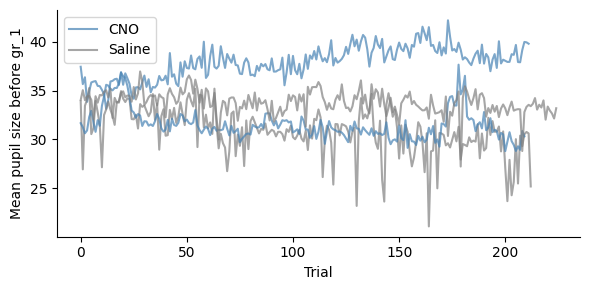

In [367]:
fig, ax = plt.subplots(figsize=(6, 3))

colors = {0: 'steelblue', 1: 'grey', 2: 'steelblue', 3: 'grey'}
labels = {0: 'CNO', 1: 'Saline', 2: None, 3: None}  # avoid duplicate legend entries

for ani in range(4):
    vals = np.nanmean(data[ani]['pupil'].values[data[ani]['grating_indices']['gr_1']][:, 11:19], axis=1)
    ax.plot(vals, color=colors[ani], alpha=0.7, label=labels[ani])

ax.set_xlabel('Trial')
ax.set_ylabel('Mean pupil size before gr_1')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()


Text(0.5, 0.98, 'gr_1')

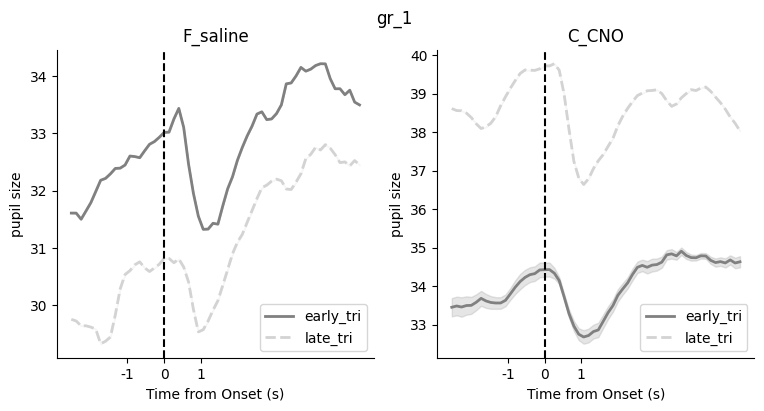

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(9,4))
ctl = [1]
tst = [0]
grat = 'gr_1'

cno = []
cno_late = []
ax = axes[0]
for _,ani in enumerate(ctl):
    cno.append(np.nanmean(data[ani]['pupil'].values[data[ani]['grating_indices'][grat]][:30,],axis=0))
    cno_late.append(np.nanmean(data[ani]['pupil'].values[data[ani]['grating_indices'][grat]][130:160,],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno),color='grey',label='early_tri')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno_late),color='lightgrey',label='late_tri',style='dash')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('pupil size')
ax.set_xticks([11.5, 19, 26.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('F_saline')

cno_late = []
ax = axes[1]
for _,ani in enumerate(tst):
    cno.append(np.nanmean(data[ani]['pupil'].values[data[ani]['grating_indices'][grat]][:30,],axis=0))
    cno_late.append(np.nanmean(data[ani]['pupil'].values[data[ani]['grating_indices'][grat]][130:160,],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno),color='grey',label='early_tri')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno_late),color='lightgrey',label='late_tri',style='dash')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('pupil size')
ax.set_xticks([11.5, 19, 26.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('C_CNO')

fig.suptitle(grat)

Text(0.5, 0.98, 'gr_2')

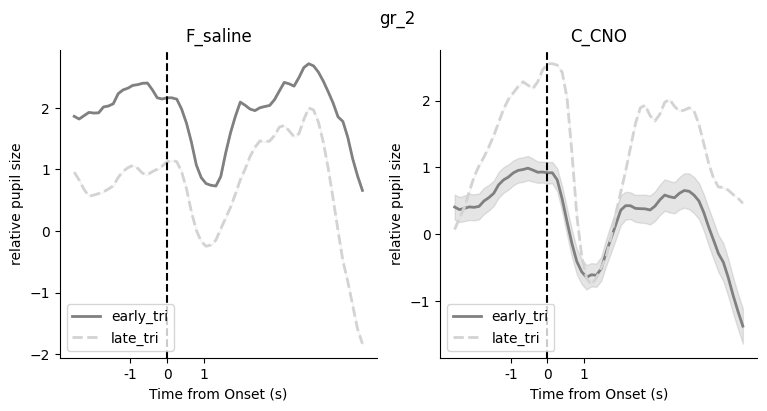

In [353]:
fig, axes = plt.subplots(1,2, figsize=(9,4))
ctl = [1]
tst = [0]
grat = 'gr_2'

cno = []
cno_late = []
ax = axes[0]
for _,ani in enumerate(ctl):
    cno.append(np.nanmean(data[ani]['pupil_rel'][grat][:30,],axis=0))
    cno_late.append(np.nanmean(data[ani]['pupil_rel'][grat][130:160,],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno),color='grey',label='early_tri')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno_late),color='lightgrey',label='late_tri',style='dash')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('relative pupil size')
ax.set_xticks([11.5, 19, 26.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('F_saline')

cno_late = []
ax = axes[1]
for _,ani in enumerate(tst):
    cno.append(np.nanmean(data[ani]['pupil_rel'][grat][:30,],axis=0))
    cno_late.append(np.nanmean(data[ani]['pupil_rel'][grat][130:160,],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno),color='grey',label='early_tri')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno_late),color='lightgrey',label='late_tri',style='dash')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('relative pupil size')
ax.set_xticks([11.5, 19, 26.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('C_CNO')

fig.suptitle(grat)

Text(0.5, 0.98, 'gr_1')

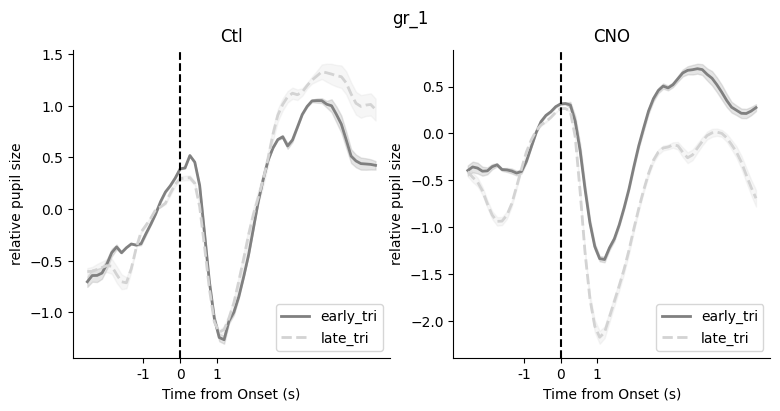

In [392]:
fig, axes = plt.subplots(1,2, figsize=(9,4))
ctl = [1,3]
tst = [0,2]
grat = 'gr_1'

cno = []
cno_late = []
ax = axes[0]
for _,ani in enumerate(ctl):
    cno.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][:30,],axis=0))
    cno_late.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][130:160,],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno),color='grey',label='early_tri')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno_late),color='lightgrey',label='late_tri',style='dash')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('relative pupil size')
ax.set_xticks([11.5, 19, 26.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('Ctl')

cno_late = []
ax = axes[1]
for _,ani in enumerate(tst):
    cno.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][:30,],axis=0))
    cno_late.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][130:160,],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno),color='grey',label='early_tri')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno_late),color='lightgrey',label='late_tri',style='dash')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('relative pupil size')
ax.set_xticks([11.5, 19, 26.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('CNO')

fig.suptitle(grat)

Text(0.5, 0.98, 'gr_2')

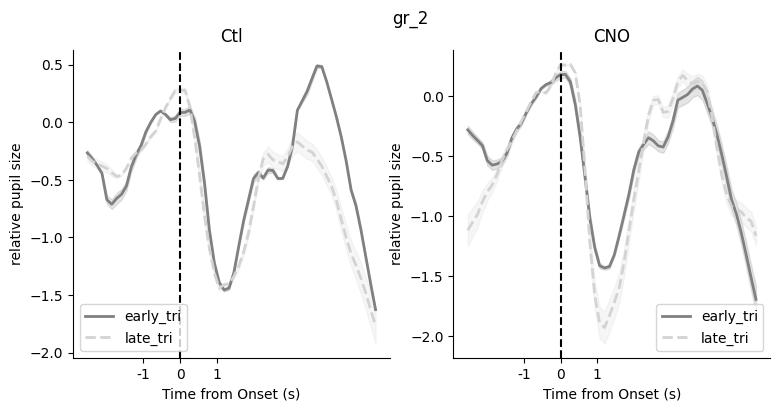

In [393]:
fig, axes = plt.subplots(1,2, figsize=(9,4))
ctl = [1,3]
tst = [0,2]
grat = 'gr_2'

cno = []
cno_late = []
ax = axes[0]
for _,ani in enumerate(ctl):
    cno.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][:30,],axis=0))
for _,ani in enumerate(tst):
    cno_late.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][:30,],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno),color='grey',label='early_tri')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno_late),color='lightgrey',label='late_tri',style='dash')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('relative pupil size')
ax.set_xticks([11.5, 19, 26.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('Ctl')

cno_late = []
ax = axes[1]
for _,ani in enumerate(tst):
    cno.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][:30,],axis=0))
    cno_late.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][130:160,],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno),color='grey',label='early_tri')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno_late),color='lightgrey',label='late_tri',style='dash')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('relative pupil size')
ax.set_xticks([11.5, 19, 26.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('CNO')

fig.suptitle(grat)

Text(0.5, 0.98, 'rew')

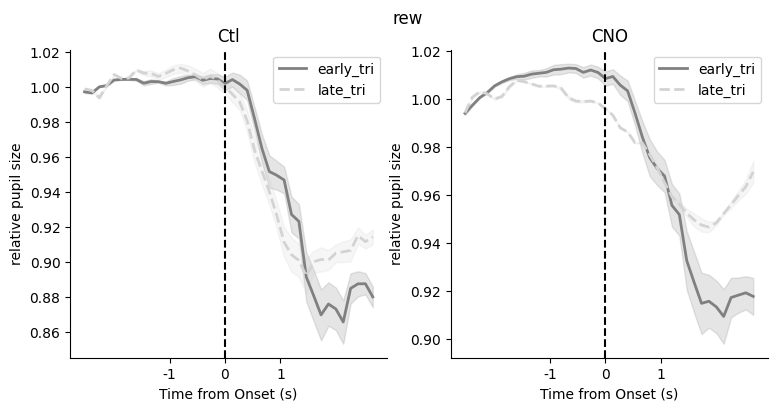

In [394]:
fig, axes = plt.subplots(1,2, figsize=(9,4))
ctl = [1,3]
tst = [0,2]
grat = 'rew'

cno = []
cno_late = []
ax = axes[0]
for _,ani in enumerate(ctl):
    cno.append(np.nanmean(data[ani]['pupil_rel'][grat][:30,],axis=0))
    cno_late.append(np.nanmean(data[ani]['pupil_rel'][grat][130:160,],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(40),data=np.vstack(cno),color='grey',label='early_tri')
viz.plot_shaded_error(ax,x_vals=np.arange(40),data=np.vstack(cno_late),color='lightgrey',label='late_tri',style='dash')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('relative pupil size')
ax.set_xticks([11.5, 19, 26.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('Ctl')

cno_late = []
ax = axes[1]
for _,ani in enumerate(tst):
    cno.append(np.nanmean(data[ani]['pupil_rel'][grat][:30,],axis=0))
    cno_late.append(np.nanmean(data[ani]['pupil_rel'][grat][130:160,],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(40),data=np.vstack(cno),color='grey',label='early_tri')
viz.plot_shaded_error(ax,x_vals=np.arange(40),data=np.vstack(cno_late),color='lightgrey',label='late_tri',style='dash')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('relative pupil size')
ax.set_xticks([11.5, 19, 26.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('CNO')

fig.suptitle(grat)

t-test:         p = 0.0084


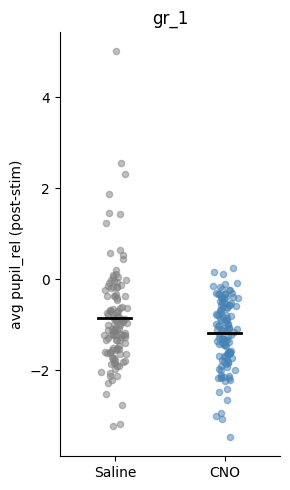

In [399]:
ctl = [1,3]
tst = [0,2]

grat = 'gr_1'
sal_means = []
cno_means = []
for ani in ctl:
    sal_means.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][:60,poststim_frames],axis=1))
for ani in tst:
    cno_means.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][:60,poststim_frames],axis=1))

sal_means = np.concatenate(sal_means)
cno_means = np.concatenate(cno_means)

fig, ax = plt.subplots(figsize=(3, 5))
np.random.seed(0)
ax.scatter(np.random.normal(1, 0.05, len(sal_means)), sal_means, color='grey', s=20, alpha=0.5, zorder=2)
ax.scatter(np.random.normal(2, 0.05, len(cno_means)), cno_means, color='steelblue', s=20, alpha=0.5, zorder=2)

for x, vals in zip([1, 2], [sal_means, cno_means]):
    ax.plot([x-0.15, x+0.15], [np.nanmean(vals)]*2, color='k', linewidth=2, zorder=3)

from scipy.stats import ttest_ind
t_stat, p_t = ttest_ind(sal_means, cno_means, nan_policy='omit')
print(f"t-test:         p = {p_t:.4f}")

ax.set_xlim([0.5, 2.5])
ax.set_xticks([1, 2])
ax.set_xticklabels(['Saline', 'CNO'])
ax.set_ylabel('avg pupil_rel (post-stim)')
ax.set_title(grat)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

t-test:         p = 0.0623


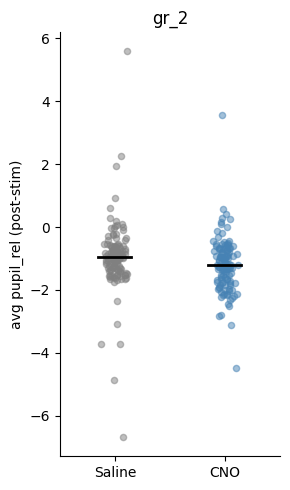

In [401]:
ctl = [1,3]
tst = [0,2]

grat = 'gr_2'
sal_means = []
cno_means = []
for ani in ctl:
    sal_means.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][:60,poststim_frames],axis=1))
for ani in tst:
    cno_means.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][:60,poststim_frames],axis=1))

sal_means = np.concatenate(sal_means)
cno_means = np.concatenate(cno_means)

fig, ax = plt.subplots(figsize=(3, 5))
np.random.seed(0)
ax.scatter(np.random.normal(1, 0.05, len(sal_means)), sal_means, color='grey', s=20, alpha=0.5, zorder=2)
ax.scatter(np.random.normal(2, 0.05, len(cno_means)), cno_means, color='steelblue', s=20, alpha=0.5, zorder=2)

for x, vals in zip([1, 2], [sal_means, cno_means]):
    ax.plot([x-0.15, x+0.15], [np.nanmean(vals)]*2, color='k', linewidth=2, zorder=3)

from scipy.stats import ttest_ind
t_stat, p_t = ttest_ind(sal_means, cno_means, nan_policy='omit')
print(f"t-test:         p = {p_t:.4f}")

ax.set_xlim([0.5, 2.5])
ax.set_xticks([1, 2])
ax.set_xticklabels(['Saline', 'CNO'])
ax.set_ylabel('avg pupil_rel (post-stim)')
ax.set_title(grat)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

t-test:         p = 0.0000


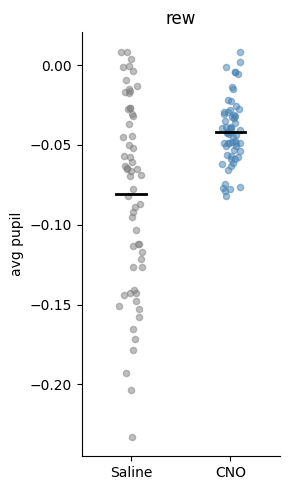

In [403]:
ctl = [1,3]
tst = [0,2]

grat = 'rew'
sal_means = []
cno_means = []
for ani in ctl:
    sal_means.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][:30,20:],axis=1))
for ani in tst:
    cno_means.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][:30,20:],axis=1))

sal_means = np.concatenate(sal_means)
cno_means = np.concatenate(cno_means)

fig, ax = plt.subplots(figsize=(3, 5))
np.random.seed(0)
ax.scatter(np.random.normal(1, 0.05, len(sal_means)), sal_means, color='grey', s=20, alpha=0.5, zorder=2)
ax.scatter(np.random.normal(2, 0.05, len(cno_means)), cno_means, color='steelblue', s=20, alpha=0.5, zorder=2)

for x, vals in zip([1, 2], [sal_means, cno_means]):
    ax.plot([x-0.15, x+0.15], [np.nanmean(vals)]*2, color='k', linewidth=2, zorder=3)

from scipy.stats import ttest_ind
t_stat, p_t = ttest_ind(sal_means, cno_means, nan_policy='omit')
print(f"t-test:         p = {p_t:.4f}")

ax.set_xlim([0.5, 2.5])
ax.set_xticks([1, 2])
ax.set_xticklabels(['Saline', 'CNO'])
ax.set_ylabel('avg pupil')
ax.set_title(grat)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()